# SentinelVision AI
## Notebook 06 — Model Comparison and Final Report

### Objective

Notebook 05 completed the modeling stack for SentinelVision AI.

This notebook compares all models, explains the strongest result, documents limitations, and summarizes the project as a finished portfolio-ready anomaly detection system.

The final model stack is:

1. Distance Threshold Baseline
2. Isolation Forest
3. Autoencoder

The flow is:

`model metrics → comparison → interpretation → limitations → business value → final conclusion`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
metrics_path = Path("../artifacts/metrics/all_model_results.csv")

results = pd.read_csv(metrics_path)

results

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261
2,Autoencoder,0.7006,0.719293,0.671587


#### Sort by PR-AUC

In [3]:
results_by_pr_auc = results.sort_values(
    by="pr_auc",
    ascending=False,
)

results_by_pr_auc

,model,roc_auc,pr_auc,f1
0,Distance Threshold Baseline,0.7400,0.742010,0.651515
1,Isolation Forest,0.7056,0.722927,0.669261
2,Autoencoder,0.7006,0.719293,0.671587


#### Sort by F1

In [4]:
results_by_f1 = results.sort_values(
    by="f1",
    ascending=False,
)

results_by_f1

,model,roc_auc,pr_auc,f1
2,Autoencoder,0.7006,0.719293,0.671587
1,Isolation Forest,0.7056,0.722927,0.669261
0,Distance Threshold Baseline,0.7400,0.742010,0.651515


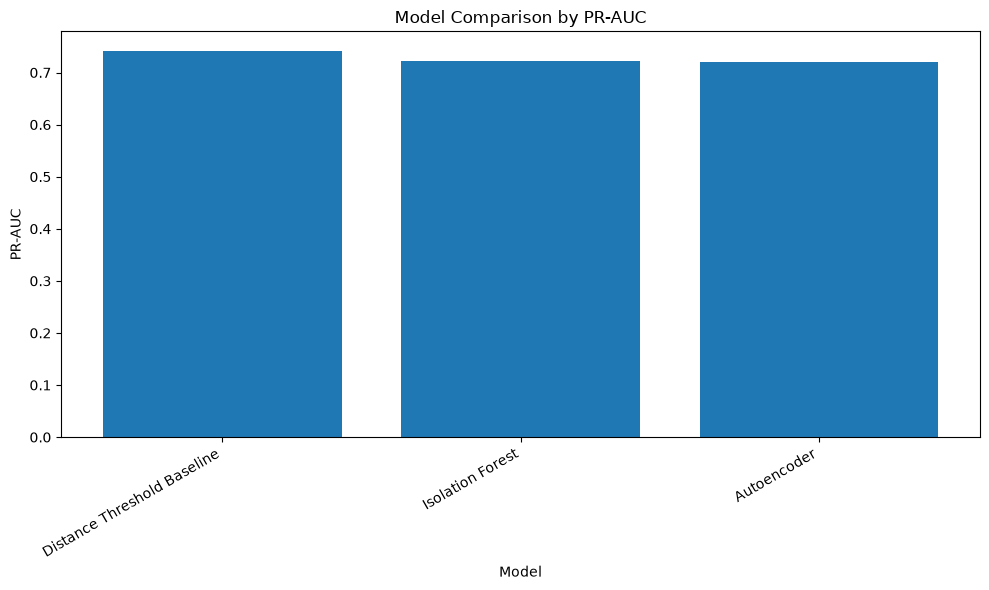

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["model"],
    results["pr_auc"],
)

plt.title("Model Comparison by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

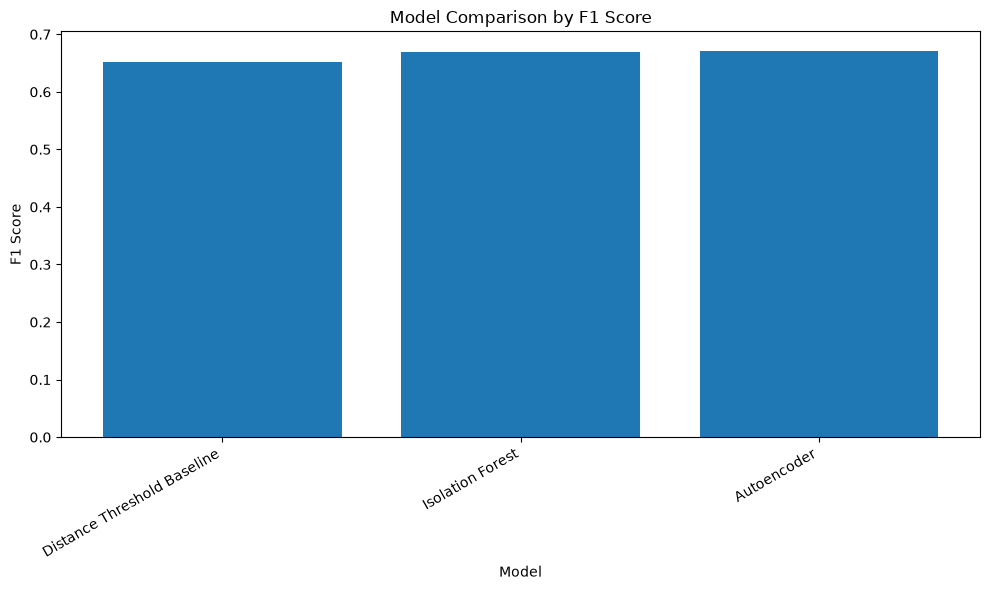

In [6]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["model"],
    results["f1"],
)

plt.title("Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### Identify best models

In [7]:
best_pr_auc_model = results.sort_values(
    by="pr_auc",
    ascending=False,
).iloc[0]

best_f1_model = results.sort_values(
    by="f1",
    ascending=False,
).iloc[0]

best_pr_auc_model

model      Distance Threshold Baseline
roc_auc                           0.74
pr_auc                         0.74201
f1                            0.651515
Name: 0, dtype: object

In [8]:
best_f1_model

model      Autoencoder
roc_auc         0.7006
pr_auc        0.719293
f1            0.671587
Name: 2, dtype: object

# Model Interpretation

The models were evaluated using weak source-video labels.

This means a clip inherited the label of its source video.

A clip from an anomalous source video may not actually contain the anomalous event.

Therefore, the results should be interpreted as weak-label clip scoring, not perfect event localization.

## Ranking Performance

The best model by PR-AUC is the strongest model for ranking suspicious clips.

This matters when the system is used to prioritize human review.

For example:

`many surveillance clips → score each clip → review the highest-risk clips first`

In this setting, PR-AUC is more important than raw accuracy.

## Thresholded Classification Performance

The best model by F1 is the strongest model after converting anomaly scores into binary predictions.

This matters when the system must produce a direct classification:

`normal` or `anomalous`

F1 is useful because it balances false positives and false negatives.

#### Create final interpretation table

In [9]:
final_interpretation = pd.DataFrame(
    {
        "question": [
            "Best model for ranking suspicious clips",
            "Best model for binary classification",
            "Most interpretable model",
            "Most production-friendly model",
        ],
        "answer": [
            best_pr_auc_model["model"],
            best_f1_model["model"],
            "Distance Threshold Baseline",
            "Distance Threshold Baseline or Isolation Forest",
        ],
    }
)

final_interpretation

,question,answer
0,Best model for ranking suspicious clips,Distance Threshold Baseline
1,Best model for binary classification,Autoencoder
2,Most interpretable model,Distance Threshold Baseline
3,Most production-friendly model,Distance Threshold Baseline or Isolation Forest


# Final Project Summary

## Problem

Surveillance systems generate large amounts of video.

Human review is expensive, slow, and inconsistent.

The goal of SentinelVision AI is to score video clips by anomaly risk so suspicious footage can be prioritized for review.

## Dataset

The project uses real-world UCF-Crime surveillance videos.

The data pipeline created:

- source-video inventory,
- video validation outputs,
- leakage-safe train, validation, and test splits,
- temporal 4-second clip windows,
- reusable clip embeddings.

## Data Pipeline

The pipeline flow was:

`raw videos → inventory → validation → source-video split → clip manifest → embeddings`

The split was performed at the source-video level to prevent clips from the same original video appearing in multiple splits.

## Modeling Approach

Three anomaly detection approaches were tested:

1. Distance Threshold Baseline
2. Isolation Forest
3. Autoencoder

Each model used clip embeddings and produced anomaly scores.

Thresholds were selected on the validation set and final performance was evaluated on the test set.

## Key Result

The final comparison showed that simple baselines were competitive with the deep autoencoder.

This is an important real-world lesson:

`more complex model ≠ automatically better model`

A simple, explainable model can be a strong first production candidate.

# Limitations

## 1. Weak clip labels

The labels come from source videos.

A clip from an anomalous video may not contain the actual anomaly.

This limits how precisely the current evaluation measures true event detection.

## 2. Simple embeddings

The current embeddings use lightweight visual statistics.

They are useful for fast baselines, but they do not capture rich motion or semantic behavior like a pretrained video model would.

## 3. Sample-based modeling

The current modeling notebooks use a balanced sample of clips.

This keeps local experimentation fast, but final production training should scale to more clips.

## 4. No frame-level localization yet

The current system scores clips.

It does not identify the exact frame where an anomaly begins or ends.

## 5. No live stream deployment yet

The project currently processes stored video clips.

A production extension would process video streams or uploaded videos through an API.

# Future Work

The next improvements should be done in this order:

1. Extract stronger pretrained CNN or video-model embeddings.
2. Scale feature extraction beyond the balanced sample.
3. Add MLflow experiment tracking.
4. Build FastAPI inference for uploaded clips.
5. Add a Gradio demo for portfolio presentation.
6. Explore weakly supervised MIL for video-level labels.

The most important next upgrade is better embeddings.

Better representations are likely to improve all downstream anomaly models.

# Business Value

SentinelVision AI is useful because it converts long surveillance footage into prioritized anomaly scores.

A practical system could help:

- security teams review high-risk clips first,
- reduce manual monitoring time,
- flag unusual events faster,
- support incident triage,
- create searchable anomaly timelines.

The system does not need to replace human reviewers.

Its strongest first use case is decision support:

`video footage → anomaly scores → ranked review queue`